In [1]:
using Gridap, GridapTopOpt

## (Serial) Minimum elastic compliance with augmented Lagrangian method in 2D.

## General Problem Discription
d = Dimension = 2 \
D = Bounding domain, subset of 𝑅𝑑 \
Ω = Sub domain, subset of D, it is the goal of optimisation, It is subjected to PDE. 

## In general Optimisation Problem: 
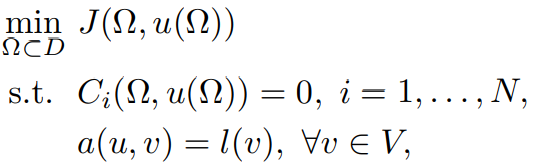

## Optimisation problem:
      Min J(Ω) = ∫ C ⊙ ε(u) ⊙ ε(v) dΩ
        Ω
    s.t., Vol(Ω) = vf,
          ⎡u∈V=H¹(Ω;u(Γ_D)=0)ᵈ,
          ⎣∫ C ⊙ ε(u) ⊙ ε(v) dΩ = ∫ v⋅g dΓ_N, ∀v∈V.

In [2]:
## FE Parameters
  order = 1                                                    # Finite element order
  xmax,ymax=(2.0,1.0)                                          # Domain size
  prop_Γ_N = 0.2                                               # Γ_N size parameter
  dom = (0,xmax,0,ymax)                                        # Bounding domain
  el_size = (400,200)                                          # Mesh partition size

(400, 200)

In [3]:
# FD parameters
  γ = 0.1                                                      # HJ eqn time step coeff
  γ_reinit = 0.5                                               # Reinit. eqn time step coeff
  max_steps = floor(Int,order*minimum(el_size)/10)             # Max steps for advection
  tol = 1/(5order^2)/minimum(el_size)                          # Reinitialisation tolerance

0.001

In [4]:
# Problem parameters
  C = isotropic_elast_tensor(2,1.,0.3)                         # C(dimension, E, ν)
  vf = 0.4                                                     # Volume fraction constraint 
  g = VectorValue(0,-1)                                        # force vector 
  iter_mod = 10                                                # VTK Output modulo
  path="./results/elastic_compliance_ALM/"
  mkpath(path)                                                 # Create path

"./results/elastic_compliance_ALM"

In [5]:
## FE Setup
model = CartesianDiscreteModel(dom,el_size)
el_Δ = get_el_Δ(model)
f_Γ_D_1(x) = (x[1] ≈ 0.0) 
f_Γ_D_2(x) = (x[1] ≈ xmax && x[2] ≈ 0.0)
f_Γ_N(x) = (x[1] <= xmax/20) && (x[2] ≈ ymax)    # Neumann boundary condition (top-left edge)  
update_labels!(1,model,f_Γ_D_1,"Gamma_D_1")
update_labels!(2,model,f_Γ_D_2,"Gamma_D_2")
update_labels!(3,model,f_Γ_N,"Gamma_N")

In [13]:
writevtk(model,"Half_MMB")

3-element Vector{Vector{String}}:
 ["Half_MMB_0.vtu"]
 ["Half_MMB_1.vtu"]
 ["Half_MMB_2.vtu"]

In [6]:
  ## Triangulations and measures
  Ω = Triangulation(model)
  Γ_N = BoundaryTriangulation(model,tags="Gamma_N")
  dΩ = Measure(Ω,2*order)
  dΓ_N = Measure(Γ_N,2*order)
  vol_D = sum(∫(1)dΩ)

1.9999999999999993

In [7]:
  ## Spaces
  reffe = ReferenceFE(lagrangian,VectorValue{2,Float64},order)
  reffe_scalar = ReferenceFE(lagrangian,Float64,order)
  V = TestFESpace(model,reffe;dirichlet_tags=["Gamma_D_1","Gamma_D_2"],dirichlet_masks=[(true,false),(false,true)])
  U = TrialFESpace(V,VectorValue(0.0,0.0))
  V_φ = TestFESpace(model,reffe_scalar)
  V_reg = TestFESpace(model,reffe_scalar;dirichlet_tags=["Gamma_N"])
  U_reg = TrialFESpace(V_reg,0)

TrialFESpace()

In [8]:
φh = interpolate(initial_lsf(4,0.2),V_φ)

SingleFieldFEFunction():
 num_cells: 80000
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 13158160679798814742

In [9]:
  η_coeff = 2
  interp = SmoothErsatzMaterialInterpolation(η = η_coeff*maximum(el_Δ))
  I,H,DH,ρ = interp.I,interp.H,interp.DH,interp.ρ
  # Weak formulation
  a(u,v,φ,dΩ,dΓ_N) = ∫((I ∘ φ)*(C ⊙ ε(u) ⊙ ε(v)))dΩ
  l(v,φ,dΩ,dΓ_N) = ∫(v⋅g)dΓ_N

l (generic function with 1 method)

In [10]:
state_map = AffineFEStateMap(a,l,U,V,V_φ,U_reg,φh,dΩ,dΓ_N)

AffineFEStateMap

In [11]:
J(u,φ,dΩ,dΓ_N) = ∫((I ∘ φ)*(C ⊙ ε(u) ⊙ ε(u)))dΩ
dJ(q,u,φ,dΩ,dΓ_N) = ∫((C ⊙ ε(u) ⊙ ε(u))*q*(DH ∘ φ)*(norm ∘ ∇(φ)))dΩ;
Vol(u,φ,dΩ,dΓ_N) = ∫(((ρ ∘ φ) - vf)/vol_D)dΩ;
dVol(q,u,φ,dΩ,dΓ_N) = ∫(-1/vol_D*q*(DH ∘ φ)*(norm ∘ ∇(φ)))dΩ
ls_evo = HamiltonJacobiEvolution(FirstOrderStencil(2,Float64),model,V_φ,tol,max_steps)
pcfs = PDEConstrainedFunctionals(J,[Vol],state_map,analytic_dJ=dJ,analytic_dC=[dVol])

PDEConstrainedFunctionals:
    num_constraints: 1

In [12]:
α_coeff = 4max_steps*γ
α = α_coeff*maximum(el_Δ)
  a_hilb(p,q) =∫(α^2*∇(p)⋅∇(q) + p*q)dΩ;
  vel_ext = VelocityExtension(a_hilb,U_reg,V_reg)

  ## Optimiser
  optimiser = AugmentedLagrangian(pcfs,ls_evo,vel_ext,φh;
    γ,γ_reinit,verbose=true,constraint_names=[:Vol])
  for (it,uh,φh) in optimiser
    data = ["φ"=>φh,"H(φ)"=>(H ∘ φh),"|∇(φ)|"=>(norm ∘ ∇(φh)),"uh"=>uh,"ρ(ϕ)"=>(ρ ∘ φh)]
    iszero(it % iter_mod) && writevtk(Ω,path*"out$it",cellfields=data)
    write_history(path*"/history.txt",optimiser.history)
  end
  it = get_history(optimiser).niter; uh = get_state(pcfs)
  writevtk(Ω,path*"out$it",cellfields=["φ"=>φh,"H(φ)"=>(H ∘ φh),"|∇(φ)|"=>(norm ∘ ∇(φh)),"uh"=>uh,"ρ(ϕ)"=>(ρ ∘ φh)])

Iteration:   0 | L=1.6699e+00, J=1.6281e+00, Vol=2.6359e-01, γ=1.0000e-01, λ1=0.0000e+00, Λ1=1.2031e+00
Iteration:   1 | L=1.5658e+00, J=1.5228e+00, Vol=2.6722e-01, γ=1.0000e-01, λ1=-3.2149e-01, Λ1=1.2031e+00
Iteration:   2 | L=1.5454e+00, J=1.4134e+00, Vol=2.7212e-01, γ=1.0000e-01, λ1=-6.4886e-01, Λ1=1.2031e+00
Iteration:   3 | L=1.5241e+00, J=1.2966e+00, Vol=2.7863e-01, γ=1.0000e-01, λ1=-9.8406e-01, Λ1=1.2031e+00
Iteration:   4 | L=1.5114e+00, J=1.1811e+00, Vol=2.8571e-01, γ=1.0000e-01, λ1=-1.3278e+00, Λ1=1.2031e+00
Iteration:   5 | L=1.5284e+00, J=1.0900e+00, Vol=2.9164e-01, γ=1.0000e-01, λ1=-1.6787e+00, Λ1=1.3234e+00
Iteration:   6 | L=1.5711e+00, J=1.0153e+00, Vol=2.9646e-01, γ=1.0000e-01, λ1=-2.0710e+00, Λ1=1.3234e+00
Iteration:   7 | L=1.6338e+00, J=9.5488e-01, Vol=2.9921e-01, γ=1.0000e-01, λ1=-2.4669e+00, Λ1=1.3234e+00
Iteration:   8 | L=1.7046e+00, J=9.0711e-01, Vol=2.9924e-01, γ=1.0000e-01, λ1=-2.8629e+00, Λ1=1.3234e+00
Iteration:   9 | L=1.7757e+00, J=8.7143e-01, Vol=2.9565e

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file://C:/Users/sif22-11/Desktop/MayankJulia/MBB_GridapTop_23_11/In[12]#16:1\[90mIn[12]:16:1[0;0m]8;;\
  writevtk(Ω,path*"out$it",cellfields=["φ"=>φh,"H(φ)"=>(H ∘ φh),"|∇(φ)|"=>(norm ∘ ∇(φh)),"uh"=>uh,"ρ(ϕ)"=>(ρ ∘ φh)])
[48;2;120;70;70mend[0;0m
[90m└─┘ ── [0;0m[91minvalid identifier[0;0m